<a href="https://colab.research.google.com/github/Dilajohn/RE-ENFORCEMENT-LEARNING-PROJECTS-/blob/main/rl_cartpole_ppo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CartPole-v1 Reinforcement Learning with PPO

This project trains and evaluates a Reinforcement Learning (RL) agent in the CartPole-v1 environment using Gymnasium and Stable-Baselines3.

## Project Overview

- **Environment:** CartPole-v1
- **Algorithm:** Proximal Policy Optimization (PPO)
- **Policy type:** Multi-Layer Perceptron (MlpPolicy)
- **RL library:** Stable-Baselines3
- **Goal:** Learn a policy that keeps a pole balanced on a moving cart for as long as possible.

## Workflow

1. Install the required libraries.
2. Create and inspect the CartPole environment.
3. Run a random agent to establish a baseline score.
4. Train a PPO agent from interaction and reward feedback.
5. Evaluate the trained agent.
6. Save the trained model for reuse.

## Result

In this run, the random agent scored 45.0, while the trained PPO agent scored 500.0. This shows that the agent learned a much better action strategy than random guessing.

install the environment and RL library:

In [14]:
!pip -q install "gymnasium[classic-control]" stable-baselines3

test that the environment works:

In [15]:
import gymnasium as gym

env = gym.make("CartPole-v1")
observation, info = env.reset()

print("Observation:", observation)
print("Action choices:", env.action_space)

Observation: [-0.02063788  0.00509924  0.03096228  0.04528787]
Action choices: Discrete(2)


The observation is the information the agent receives, while the action space tells you which moves it is allowed to make.

Run a completely random agent first. This gives you a baseline before training

In [16]:
total_reward = 0
observation, info = env.reset()

for step in range(500):
    action = env.action_space.sample()
    observation, reward, terminated, truncated, info = env.step(action)
    total_reward += reward

    if terminated or truncated:
        break

print("Random-agent reward:", total_reward)

Random-agent reward: 13.0


Train a PPO agent:

In [17]:
from stable_baselines3 import PPO

model = PPO("MlpPolicy", env, verbose=1)
model.learn(total_timesteps=20_000)
model.save("cartpole_ppo")

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 21.7     |
|    ep_rew_mean     | 21.7     |
| time/              |          |
|    fps             | 1285     |
|    iterations      | 1        |
|    time_elapsed    | 1        |
|    total_timesteps | 2048     |
---------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 24.5        |
|    ep_rew_mean          | 24.5        |
| time/                   |             |
|    fps                  | 494         |
|    iterations           | 2           |
|    time_elapsed         | 8           |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.009423032 |
|    clip_fraction        | 0.109       |
|    clip_range           | 0.2         |
|    entropy_loss   

Evaluate what it learned:

In [18]:
observation, info = env.reset()
total_reward = 0

for step in range(500):
    action, _states = model.predict(observation, deterministic=True)
    observation, reward, terminated, truncated, info = env.step(action)
    total_reward += reward

    if terminated or truncated:
        break

print("Trained-agent reward:", total_reward)

Trained-agent reward: 500.0


In [19]:
from stable_baselines3 import PPO
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

# 1. Re-create the environment
env = gym.make("CartPole-v1")

# 2. Load the trained model you just saved
model = PPO.load("cartpole_ppo", env=env)

# 3. Run many evaluation episodes and collect rewards
def evaluate_policy(model, env, n_eval_episodes=10, deterministic=True):
    episode_rewards = []

    for _ in range(n_eval_episodes):
        obs, _ = env.reset()
        done = False
        truncated = False
        total_reward = 0

        while not (done or truncated):
            action, _ = model.predict(obs, deterministic=deterministic)
            obs, reward, done, truncated, _ = env.step(action)
            total_reward += float(reward)

        episode_rewards.append(total_reward)

    mean_reward = np.mean(episode_rewards)
    std_reward = np.std(episode_rewards)
    return mean_reward, std_reward, episode_rewards

# 4. Evaluate the trained policy
mean_reward, std_reward, rewards = evaluate_policy(model, env, n_eval_episodes=10)

print(f"Mean reward over 10 episodes: {mean_reward:.2f} ± {std_reward:.2f}")
print("Individual episode rewards:", rewards)

Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Mean reward over 10 episodes: 500.00 ± 0.00
Individual episode rewards: [500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0]


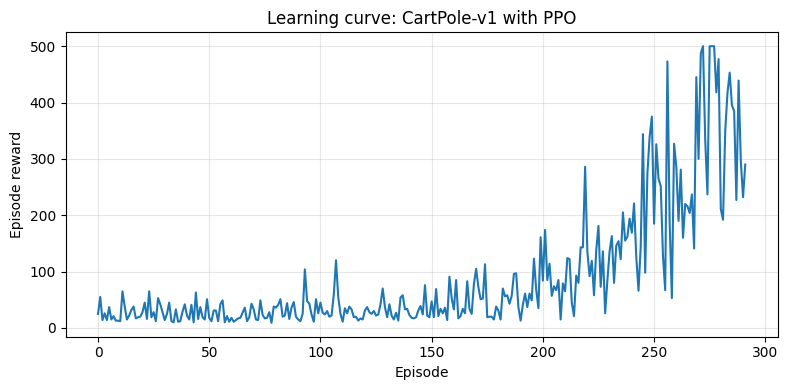

In [20]:
from stable_baselines3.common.callbacks import BaseCallback
from stable_baselines3 import PPO
import gymnasium as gym
import matplotlib.pyplot as plt

# Custom callback to store episode rewards during training
class RewardCallback(BaseCallback):
    def __init__(self, verbose=0):
        super().__init__(verbose)
        self.episode_rewards = []

    def _on_step(self) -> bool:
        # infos contains episode information when an episode ends
        if "episode" in self.locals.get("infos", [{}])[0]:
            info = self.locals["infos"][0]["episode"]
            self.episode_rewards.append(info["r"])
        return True

# 1. Create environment again
env = gym.make("CartPole-v1")

# 2. Create callback
reward_callback = RewardCallback()

# 3. Train a new model while recording rewards
model2 = PPO("MlpPolicy", env, verbose=0, n_steps=2048, seed=0)
model2.learn(total_timesteps=25_000, callback=reward_callback)

# 4. Plot reward over episodes
plt.figure(figsize=(8, 4))
plt.plot(reward_callback.episode_rewards)
plt.xlabel("Episode")
plt.ylabel("Episode reward")
plt.title("Learning curve: CartPole-v1 with PPO")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()